# Filter Experimentation
### Purpose: Systematically identify the top 3 filters that best enhance tree canopy boundaries

## Notebook guidance
- Experiments with image filters; confirm input image dirs and filter settings upfront.
- Start with a few samples to gauge effect before running full dataset.
- Check outputs/plots to ensure filters align with later training preprocessing.


In [1]:
import os
import sys
from pathlib import Path

from dotenv import load_dotenv

load_dotenv()
_start = Path(os.getenv("PROJECT_ROOT") or Path.cwd()).resolve()
root = next(p for p in [_start, *_start.parents] if (p / "config.yaml").exists())
sys.path[:0] = [str(root), str(root / "src")]

from src.training.running import get_available_filters

import random
import cv2
import numpy as np
import pandas as pd

from src.data.annotations import load_json_annotations
from src.exploration.visualize import show_side_by_side
from src.utils.config import Config
from src.utils.helpers import c, init_notebook, p, t
from src.data.image_loader import apply_all_filters, create_enhanced_image

config = Config.load(root = root)
init_notebook(config.train.seed)

train_dir = config.paths.train_images
annotations_path = config.paths.annotations
entries = load_json_annotations(annotations_path)



=== init_notebook ===
Done


#### Step 1: Define Filter Candidates

Test these filters based on computer vision theory:

**Edge Detection:**
- Sobel (X, Y, combined) - First derivative, directional
- Laplacian - Second derivative, isotropic
- Scharr - Enhanced Sobel

**Contrast Enhancement:**
- CLAHE - Adaptive histogram equalization
- Histogram Equalization - Global contrast

**Noise Reduction:**
- Gaussian Blur - Smoothing before edge detection

**Custom Kernels:**
- High-pass filter - Emphasizes edges
- Sharpening - Enhances boundaries


In [2]:
def load_sample_with_mask( config, entry ):
    """Load image and its ground truth mask."""
    img_path = config.paths.train_images / entry.image_path.name
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    mask = entry.to_mask()
    return img, mask

def compute_edge_quality( filtered_img, ground_truth_mask, threshold = 0.5 ):
    """
    Measure how well filter output aligns with true canopy edges.
    
    Returns:
        edge_iou: IoU between detected edges and mask boundaries
        edge_precision: Precision of edge detection
        edge_recall: Recall of edge detection
    """
    # Get edges from ground truth mask
    mask_edges = cv2.Canny(ground_truth_mask.astype(np.uint8) * 255, 50, 150)

    # Normalize filtered image
    if filtered_img.dtype != np.uint8:
        filtered_norm = cv2.normalize(filtered_img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    else:
        filtered_norm = filtered_img

    # Detect edges in filtered image
    if len(filtered_norm.shape) == 3:
        filtered_gray = cv2.cvtColor(filtered_norm, cv2.COLOR_RGB2GRAY)
    else:
        filtered_gray = filtered_norm

    detected_edges = cv2.Canny(filtered_gray, 50, 150)

    # Compute metrics
    mask_edges_bin = (mask_edges > 0).astype(np.uint8)
    detected_edges_bin = (detected_edges > 0).astype(np.uint8)

    tp = np.logical_and(detected_edges_bin == 1, mask_edges_bin == 1).sum()
    fp = np.logical_and(detected_edges_bin == 1, mask_edges_bin == 0).sum()
    fn = np.logical_and(detected_edges_bin == 0, mask_edges_bin == 1).sum()

    precision = tp / (tp + fp + 1e-8)
    recall = tp / (tp + fn + 1e-8)
    iou = tp / (tp + fp + fn + 1e-8)

    return {
        'edge_iou':       float(iou),
        'edge_precision': float(precision),
        'edge_recall':    float(recall),
        'edge_f1':        float(2 * precision * recall / (precision + recall + 1e-8))
    }


#### Step 3: Quantitative Evaluation


In [3]:
from src.exploration.kernels import get_kernels, apply_kernel_using_convolution
from src.exploration.enhancement import to_gray, clahe_enhance
from src.exploration.filters import cv2_apply_laplacian, cv2_apply_sobel

# Select random samples for testing
num_samples = min(10, len(entries))
sample_entries = random.sample(entries, num_samples)

# Get all available kernels
kernel_bank = get_kernels("all")  # returns dict of {name: kernel_matrix}

t("Evaluating all kernels from get_kernels()")

results = []

for idx, sample_entry in enumerate(sample_entries):

    p(f"Processing sample {idx + 1}/{len(sample_entries)}", sample_entry.image_path.name)

    # Load image and mask
    img, mask = load_sample_with_mask(config, sample_entry)
    gray = to_gray(img)

    # Evaluating all kernels from kernel bank
    for kname, kernel in kernel_bank.items():

        # apply kernel
        try:
            filtered = apply_kernel_using_convolution(gray, kernel)

            # compute metrics
            metrics = compute_edge_quality(filtered, mask)

            results.append(
                    {
                        'image':  sample_entry.image_path.name,
                        'filter': kname.lower(),
                        **metrics
                    }
            )
        except Exception as e:
            p("Warning", f"Kernel {kname} failed: {e}")
            continue

    # Evaluate algorithmic filters (OpenCV native)
    algorithmic_filters = {
        'laplacian':    lambda: cv2_apply_laplacian(img),
        'sobel':        lambda: cv2_apply_sobel(img),
        'clahe':        lambda: clahe_enhance(gray, clip = 2.0, tile = 8),
        'gaussian_3x3': lambda: cv2.GaussianBlur(gray, (3, 3), 1.0),
        'gaussian_5x5': lambda: cv2.GaussianBlur(gray, (5, 5), 1.5),
    }

    # Evaluate algorithmic filters (OpenCV native)
    for fname, filter_func in algorithmic_filters.items():
        try:
            filtered = filter_func()

            # Normalize if needed
            if filtered.dtype != np.uint8:
                filtered = cv2.normalize(filtered, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

            metrics = compute_edge_quality(filtered, mask)

            results.append(
                    {
                        'image':       sample_entry.image_path.name,
                        'filter':      fname,
                        'filter_type': 'algorithmic',
                        **metrics
                    }
            )
        except Exception as e:
            p("Warning", f"Filter '{fname}' failed: {e}", color1 = c.ORANGE)
            continue

# Convert to DataFrame
df = pd.DataFrame(results)
t(f"Evaluation complete: {len(results)} filter-image combinations tested")


=== Evaluating all kernels from get_kernels() ===
Processing sample 1/10: neon_DSNY_025_2018.png
Processing sample 2/10: neon_2018_SJER_3_254000_4108000_image_700.png
Processing sample 3/10: neon_2018_SJER_3_252000_4106000_image_234.png
Processing sample 4/10: neon_ABBY_076_2019.png
Processing sample 5/10: neon_ABBY_063_2019.png
Processing sample 6/10: neon_DSNY_002_2018.png
Processing sample 7/10: neon_2018_TEAK_3_318000_4107000_image_718.png
Processing sample 8/10: neon_BART_050_2019.png
Processing sample 9/10: neon_JERC_055_2018.png
Processing sample 10/10: neon_OSBS_051_2019.png
=== Evaluation complete: 410 filter-image combinations tested ===


#### Step 4: Rank Filters by Performance


In [4]:
# Aggregate metrics across all images
t("Filter Performance Summary")

summary = df.groupby('filter').agg(
        {
            'edge_iou':       ['mean', 'std'],
            'edge_precision': ['mean', 'std'],
            'edge_recall':    ['mean', 'std'],
            'edge_f1':        ['mean', 'std']
        }
).round(4)

summary.columns = ['_'.join(col).strip() for col in summary.columns.values]
summary = summary.sort_values('edge_f1_mean', ascending = False)

p("Top filters by F1 score", summary.head(10))

# Identify top 3
top_3_filters = summary.head(3).index.tolist()
p("Top 3 Filters", top_3_filters)


=== Filter Performance Summary ===
Top filters by F1 score:                      edge_iou_mean  edge_iou_std  edge_precision_mean  \
filter                                                                  
laplacian_3x3               0.0159        0.0149               0.0170   
gradient_magnitude          0.0158        0.0156               0.0166   
motion_blur_9x9             0.0157        0.0143               0.0245   
gaussian_3x3_sigma2         0.0154        0.0129               0.0175   
motion_blur_5x5             0.0154        0.0139               0.0182   
gaussian_2x2_sigma2         0.0154        0.0129               0.0175   
cv2_gaussian_5x5            0.0153        0.0126               0.0181   
gaussian_5x5_sigma1         0.0153        0.0126               0.0181   
box_blur_3x3                0.0153        0.0128               0.0174   
laplacian                   0.0153        0.0145               0.0163   

                     edge_precision_std  edge_recall_mean  edge

#### Step 5: Visual Comparison


In [5]:
def apply_filters_safely( img, filter_names ):
    """
    Apply filters with error handling.
    """
    try:
        return apply_all_filters(img)
    except Exception as e:
        p("Filter application failed", str(e), color1 = c.RED)
        return { }

def validate_filter_compatibility( filter_names, available_filters ):
    """
    Check if all filters are available.
    """
    missing = [f for f in filter_names if f not in available_filters]
    if missing:
        p("Missing filters", missing, color1 = c.ORANGE)
        return False
    return True

for sample_entry in sample_entries:
    try:
        img, mask = load_sample_with_mask(config, sample_entry)

        # Apply filters safely
        filters = apply_filters_safely(img, get_available_filters())

        if not filters:
            p("No filters applied successfully", color1 = c.ORANGE)
            continue

        # Continue with existing logic...

    except Exception as e:
        p("Failed to process entry", str(e), color1 = c.RED)
        continue


=== Visual comparison: neon_DSNY_025_2018.png ===


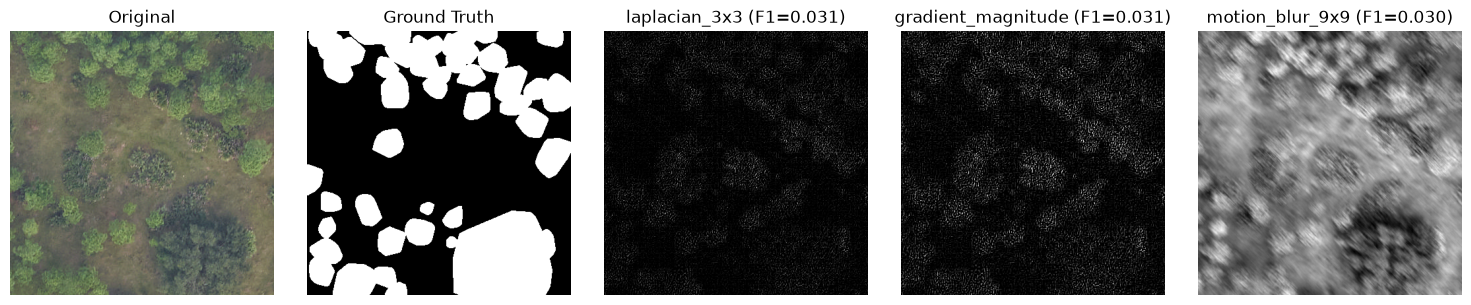

In [6]:
# Visualize top 3 filters on a sample image
sample_entry = sample_entries[0]
img, mask = load_sample_with_mask(config, sample_entry)
filters = apply_all_filters(img)

t(f"Visual comparison: {sample_entry.image_path.name}")

# Show original, mask, and top 3 filters
images_to_show = [img, mask]
titles = ['Original', 'Ground Truth']

for fname in top_3_filters:
    images_to_show.append(filters[fname])
    titles.append(f"{fname} (F1={summary.loc[fname, 'edge_f1_mean']:.3f})")

show_side_by_side(
        *images_to_show,
        titles = tuple(titles),
        cmaps = tuple([None, 'gray'] + ['gray'] * len(top_3_filters))
)


#### Step 6: Combining Multiple Filters Strategy

**Create a 3-channel "enhanced" image using the top 3 filters as RGB channels.**


=== Multi-channel Enhanced Image ===


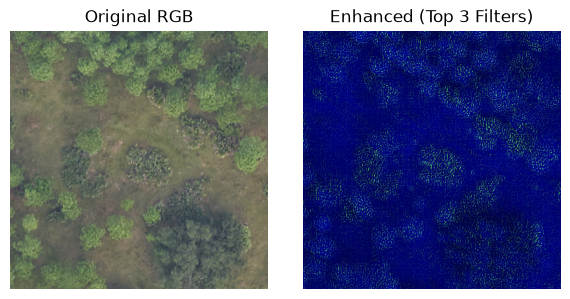

In [7]:
# Test on sample
enhanced_img = create_enhanced_image(img, top_3_filters)

t("Multi-channel Enhanced Image")
show_side_by_side(
        img,
        enhanced_img,
        titles = ("Original RGB", f"Enhanced (Top 3 Filters)")
)


#### Step 7: Export Results


In [8]:
# Save detailed results
output_path = config.paths.models / "filter_analysis.csv"
df.to_csv(output_path, index = False)
p("Saved detailed results", output_path)

# Save summary
summary_path = config.paths.models / "filter_summary.csv"
summary.to_csv(summary_path)
p("Saved summary", summary_path)

# Save top 3 filters to config
p("TOP_3_FILTERS", top_3_filters)


Saved detailed results: /Volumes/Colibri/Projects/cap6415-tree-canopy-detection/checkpoints/filter_analysis.csv
Saved summary: /Volumes/Colibri/Projects/cap6415-tree-canopy-detection/checkpoints/filter_summary.csv
TOP_3_FILTERS: 3 items
  0: laplacian_3x3
  1: gradient_magnitude
  2: motion_blur_9x9


#### Step 8: Comparison Visualization Grid


=== Comprehensive Filter Comparison ===


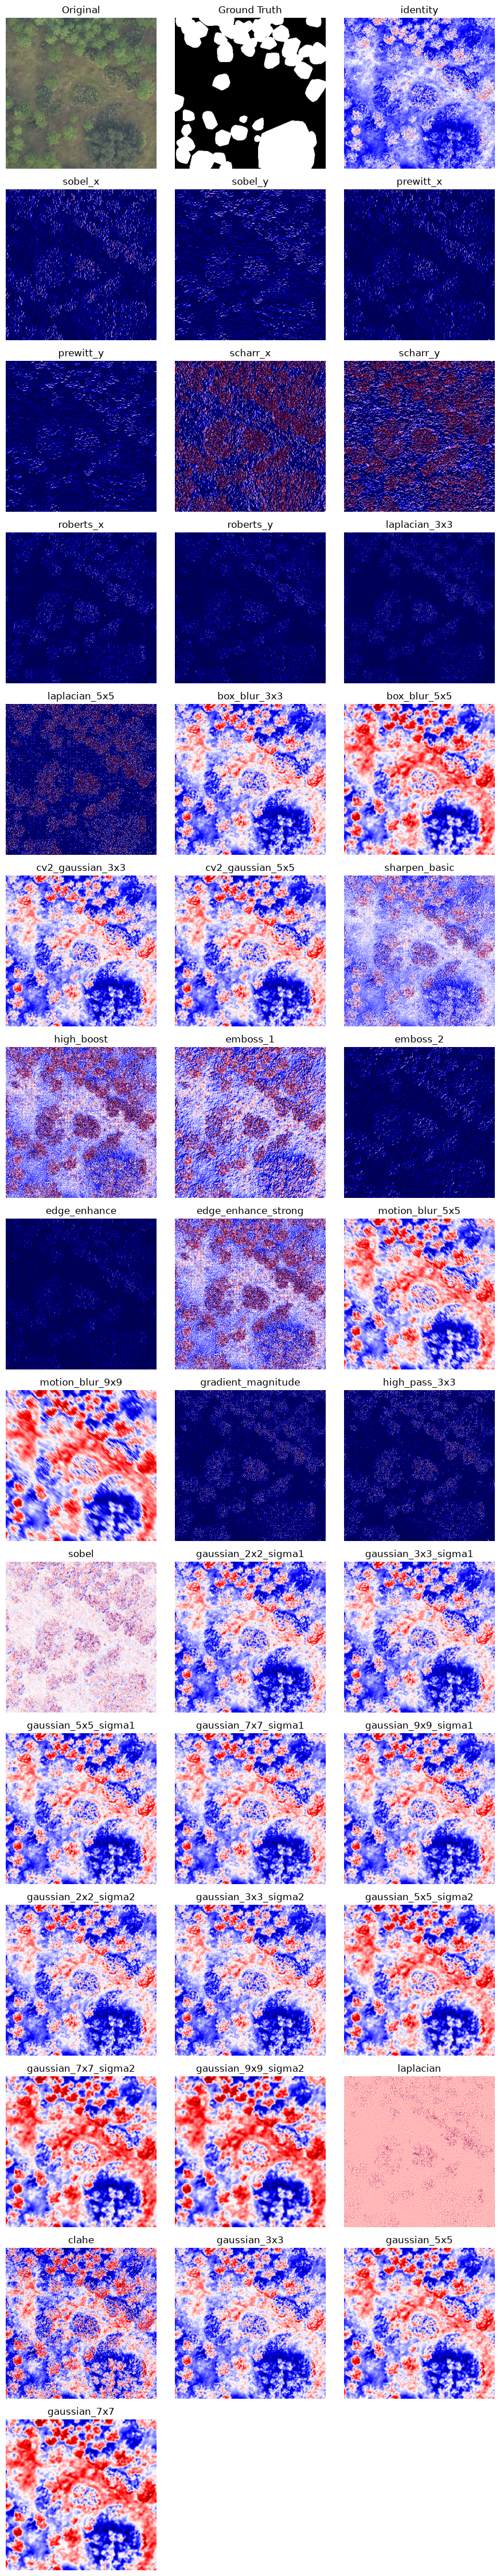

In [9]:
# Create comprehensive comparison for one image
t("Comprehensive Filter Comparison")

sample_entry = sample_entries[0]
img, mask = load_sample_with_mask(config, sample_entry)
filters = apply_all_filters(img)

# Prepare all filters for visualization
all_filters = list(filters.keys())
images = [img, mask] + [filters[f] for f in all_filters]
titles_all = ['Original', 'Ground Truth'] + all_filters

cmaps_all = [None, 'gray'] + ['seismic'] * len(all_filters)

show_side_by_side(
        *images,
        titles = tuple(titles_all),
        cmaps = tuple(cmaps_all),
        maxcolumns = 3,
        figsize = 3
)
